**Import Libraries**

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.ticker as mtick
import plotly.express as ex
from imblearn.over_sampling import SMOTE

%matplotlib inline
background_color = "#f6f6f6"


**Load Dataset**

In [38]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
# This path now works for both you and your team members
df = pd.read_csv('/content/drive/MyDrive/healthcare-dataset-stroke-data.csv')

# df = pd.read_csv("/healthcare-dataset-stroke-data.csv")
df.sample(5)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1832,23988,Female,45.0,0,0,Yes,Private,Rural,76.68,34.8,smokes,0
1701,4789,Male,8.0,0,0,No,children,Rural,91.54,13.4,Other,0
2724,19335,Male,58.0,0,0,Yes,Self-employed,Rural,99.83,36.3,smokes,0
1556,18754,Male,19.0,0,0,No,Self-employed,Rural,82.07,29.0,never smoked,0
4856,31254,Female,20.0,0,0,No,Private,Urban,96.69,24.6,Other,0


**Check Dataset Size**

In [39]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 5110
Number of columns: 12


**Display Columns and it data type**

In [40]:
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


**Check missing value**

In [41]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


The id column is only a patient identifier.
It does not represent a meaningful health characteristic.

**Remove ID Column**

In [42]:
df = df.drop('id', axis=1)

In [43]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.9,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Check Duplicate Data**

In [44]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Data cleaning fixes**

Two issues in the raw data need handling before modeling:

1. **Missing `bmi` values (201 rows)** — imputed with the median.
2. **Rare `'Other'` category in `gender` (1 row)** — removed. It's also too small a sample (n=1) for the model to learn anything from, and would break the EDA bar charts below since it creates a mismatched category count between the stroke/no-stroke groups.


In [45]:
print("Missing bmi before:", df['bmi'].isnull().sum())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
print("Missing bmi after:", df['bmi'].isnull().sum())


Missing bmi before: 0
Missing bmi after: 0


In [46]:
print("Rows before:", df.shape[0])
df = df[df['gender'] != 'Other']
print("Rows after removing 'Other' gender:", df.shape[0])


Rows before: 5110
Rows after removing 'Other' gender: 5110


# Explore Data Analysis

In [47]:
fig = ex.pie(df, names='stroke', color_discrete_sequence=['#17BECF', '#FFC20A'])
fig.update_layout(title='<b>Proportion Of Stroke Samples<b>')
fig.show()


we can cearly see the dataset is unbalanced , so we will oversampling it using SMOTE approach in the futere

**Age Distribution**

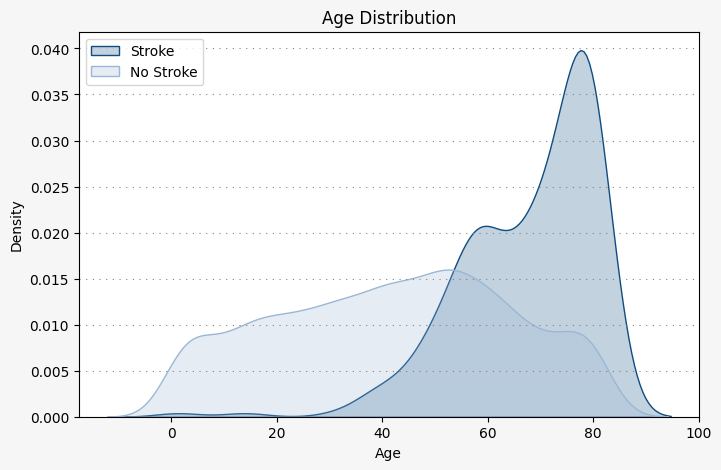

In [48]:
str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

ax.grid(color='gray', linestyle=':', axis='y', dashes=(1,5))

positive = pd.DataFrame(str_only["age"])
negative = pd.DataFrame(no_str_only["age"])

sns.kdeplot(positive["age"], ax=ax, color="#0f4c81", fill=True, label="Stroke")
sns.kdeplot(negative["age"], ax=ax, color="#9bb7d4", fill=True, label="No Stroke")

ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()

plt.show()


**Smoking Status**

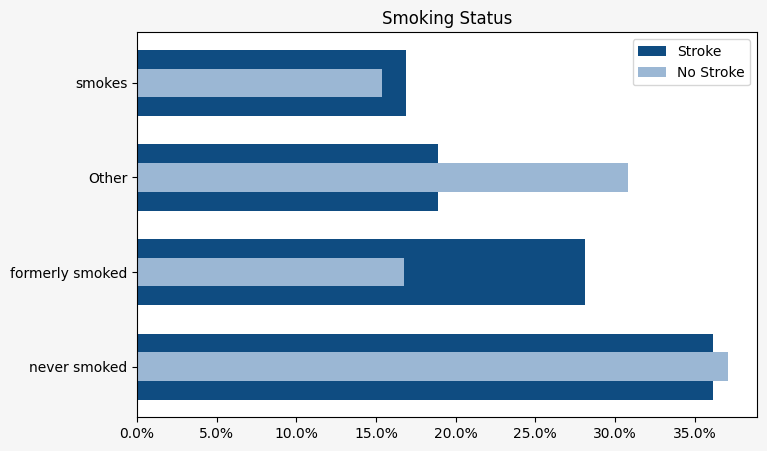

In [49]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["smoking_status"].value_counts())
positive["Percentage"] = (positive["count"] / positive["count"].sum()) * 100

negative = pd.DataFrame(no_str_only["smoking_status"].value_counts())
negative["Percentage"] = (negative["count"] / negative["count"].sum()) * 100

ax.barh(positive.index, positive["Percentage"], color="#0f4c81", height=0.7, label="Stroke")
ax.barh(negative.index, negative["Percentage"], color="#9bb7d4", height=0.3, label="No Stroke")

ax.set_title("Smoking Status")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

plt.show()


**Gender**

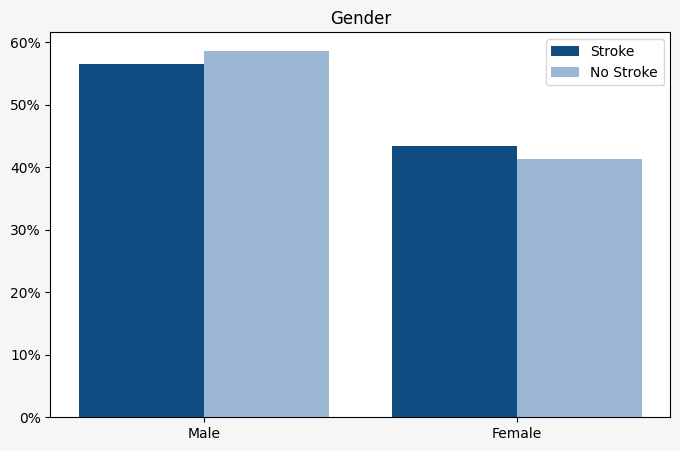

In [50]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["gender"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["gender"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["Male","Female"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Gender")
ax.legend()

plt.show()


**Heart Disease**

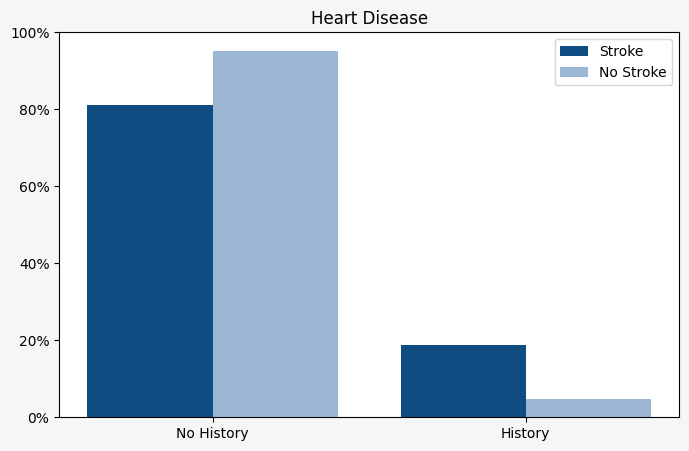

In [51]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["heart_disease"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["heart_disease"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Heart Disease")
ax.legend()

plt.show()


**Average Glucose Level**

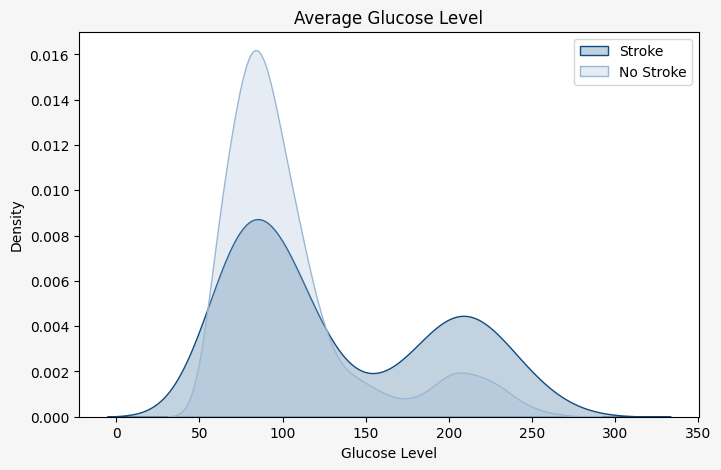

In [52]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["avg_glucose_level"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["avg_glucose_level"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("Average Glucose Level")
ax.set_xlabel("Glucose Level")
ax.legend()

plt.show()


**BMI**

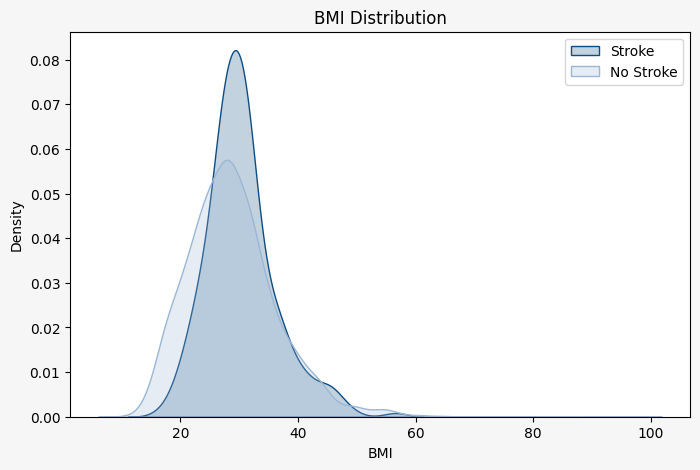

In [53]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["bmi"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["bmi"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("BMI Distribution")
ax.set_xlabel("BMI")
ax.legend()

plt.show()


**Work Type**

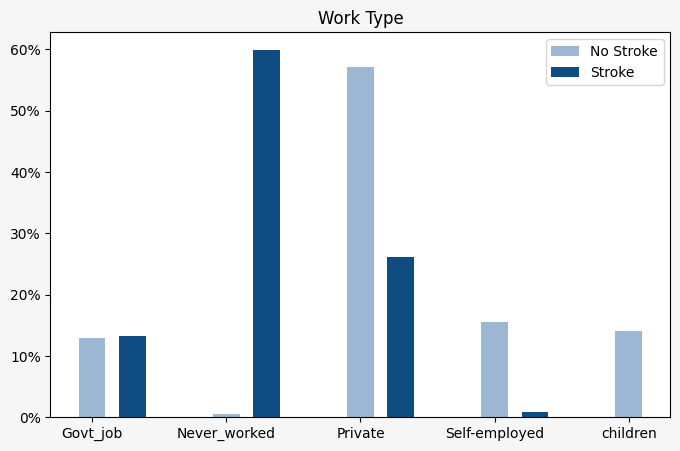

In [54]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["work_type"].value_counts()).sort_index()
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["work_type"].value_counts()).sort_index()
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

ax.bar(negative.index, negative["Percentage"], width=0.2, color="#9bb7d4", label="No Stroke")
ax.bar(np.arange(len(positive))+0.3, positive["Percentage"], width=0.2, color="#0f4c81", label="Stroke")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Work Type")
ax.legend()

plt.show()


**Hypertension**

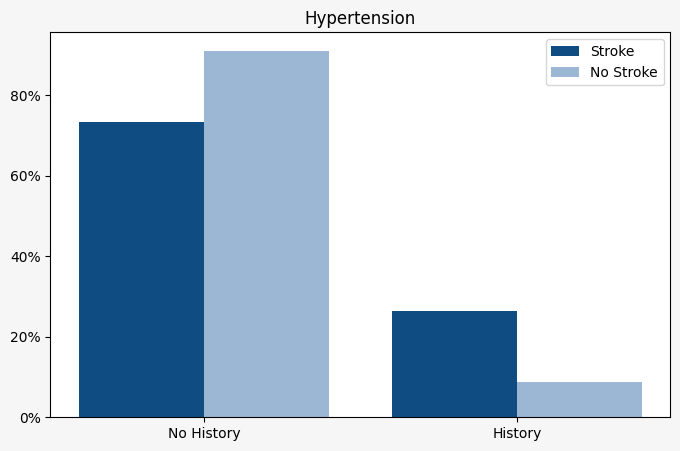

In [55]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["hypertension"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["hypertension"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Hypertension")
ax.legend()

plt.show()


**Find unique data in each column**

In [56]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')


gender : ['Male' 'Female']
ever_married : ['Yes' 'No']
work_type : ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type : ['Urban' 'Rural']
smoking_status : ['formerly smoked' 'never smoked' 'smokes' 'Other']


# Label Encoding

**ever_married**

Note: `df[col].replace(..., inplace=True)` is avoided here — with newer pandas versions (copy-on-write),
this chained-assignment pattern silently fails to update the DataFrame. Using `df[col] = df[col].replace(...)`
instead, which is safe on all pandas versions.


In [57]:
df['ever_married'] = df['ever_married'].replace({'Yes':1,'No':0})

/tmp/ipykernel_654/1086586040.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [58]:
print(f'ever_married : {df["ever_married"].unique()}')

ever_married : [1 0]


**convert into integer**

In [59]:
df.ever_married=pd.to_numeric(df.ever_married)

**gender**

In [60]:
df['gender'] = df['gender'].replace({'Male':1,'Female':0})

/tmp/ipykernel_654/2630065490.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [61]:
print(f'gender : {df["gender"].unique()}')

gender : [1 0]


**convert into integer**

In [62]:
df.gender=pd.to_numeric(df.gender)

# One Hot Encoding

In [63]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')


work_type : ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type : ['Urban' 'Rural']
smoking_status : ['formerly smoked' 'never smoked' 'smokes' 'Other']


**now we will use one hot encoding for work type ,resisdent type and smoking status**

In [64]:
df=pd.get_dummies(data=df,columns=['work_type','Residence_type','smoking_status'])
df.sample(5)


,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Other,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
4884,0,62.0,0,0,1,110.84,23.4,0,True,False,False,False,False,False,True,False,False,False,True
2108,0,22.0,0,0,0,73.50,41.3,0,False,False,True,False,False,False,True,False,False,False,True
925,0,7.0,0,0,0,61.68,16.4,0,False,False,False,False,True,False,True,True,False,False,False
4471,1,56.0,0,0,1,93.72,31.4,0,False,False,True,False,False,True,False,False,False,True,False
2060,1,59.0,0,0,1,93.90,42.2,0,False,False,True,False,False,True,False,False,False,True,False


In [65]:
df.dtypes

,0
gender,int64
age,float64
hypertension,int64
heart_disease,int64
ever_married,int64
avg_glucose_level,float64
bmi,float64
stroke,int64
work_type_Govt_job,bool
work_type_Never_worked,bool


# Train/Test Split (Split-First Logic)

**Critical fix:** `MinMaxScaler` and `SMOTE` were previously fit on the *whole* dataset before splitting (old cells: global `scaler.fit_transform(df[...])`, and `smote.fit_resample(X, y)` applied before `train_test_split`). That leaks test-set information into training in two ways:

1. The scaler's min/max were learned using test rows, so `X_test` was scaled using statistics it shouldn't have had access to.
2. SMOTE generated synthetic minority samples using neighbor information from what later became `X_test`, and — worse — synthetic points interpolated from a real test-set neighbor could end up training the model on something very close to a test observation.

Both inflate reported accuracy. The fix: split **first**, on the raw (unscaled, imbalanced) data, and do everything else only inside the training fold.

In [66]:
X = df.drop('stroke', axis='columns')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train class balance:\n", y_train.value_counts())
print("y_test class balance:\n", y_test.value_counts())


X_train: (4088, 18)  X_test: (1022, 18)
y_train class balance:
 stroke
0    3889
1     199
Name: count, dtype: int64
y_test class balance:
 stroke
0    972
1     50
Name: count, dtype: int64


# Pipeline: Scaler + SMOTE + SVM

`sklearn.pipeline.Pipeline` can't hold SMOTE — SMOTE changes the number of rows (`n_samples` in ≠ out), and plain `Pipeline` only accepts steps that preserve sample count. We use **`imblearn.pipeline.Pipeline`** instead. Its key behaviour is exactly what we need:
- During `.fit()`, every step (including SMOTE) runs on the training fold.
- During `.predict()` / `.transform()`, resampling steps (SMOTE) are **automatically skipped** — only the scaler's `.transform()` is applied.

So `MinMaxScaler` is *fit* on `X_train` and only ever *transforms* `X_test`, and SMOTE never sees `X_test` at all.

In [67]:
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(random_state=42))
])


# GridSearchCV over Kernels, C, and Gamma

Instead of four separate manual sections (Linear / RBF / Poly / Sigmoid), one `GridSearchCV` searches all kernels and their relevant hyperparameters together. Each kernel gets its own dict in the `param_grid` list, since `gamma`/`degree` only apply to some kernels — this avoids wasting grid points testing e.g. `gamma` values against the linear kernel, where it's unused.

Because `pipeline` is used (not a bare `SVC`), every fold inside `GridSearchCV`'s cross-validation re-fits the scaler and re-applies SMOTE using *only that fold's training data* — so the leakage fix holds even during hyperparameter search, not just for the final train/test split.

`scoring='f1'` is used below since the classes are imbalanced (accuracy alone can look great by just predicting "no stroke" every time). If missing an actual stroke case (false negative) is more costly than a false alarm in your context, switch `scoring` to `'recall'` instead.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 'auto'],
        'svm__degree': [2, 3, 4]
    },
    {
        'svm__kernel': ['sigmoid'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1]
    },
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Best kernel/params:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)


Fitting 5 folds for each of 55 candidates, totalling 275 fits
Best kernel/params: {'svm__C': 100, 'svm__kernel': 'linear'}
Best CV F1 score: 0.2262905040282175


**Evaluate the best model on the held-out, untouched `X_test`**

In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))


Test Accuracy: 0.7318982387475538

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.73      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.73      0.81      1022



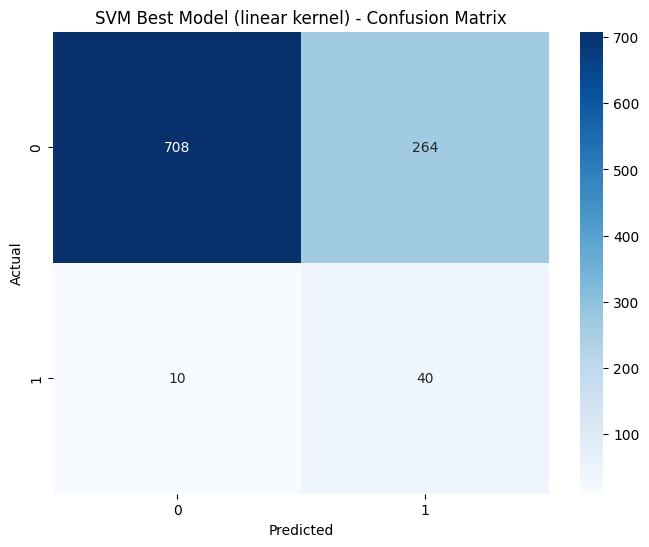

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f"SVM Best Model ({grid_search.best_params_['svm__kernel']} kernel) - Confusion Matrix")
plt.show()


## Kernel Comparison (from GridSearchCV results)

Rather than training each kernel separately (old Part 1–4 cells), pull the best CV score achieved *for each kernel* directly out of `grid_search.cv_results_` — every candidate was already evaluated during the search above, so no extra fitting is needed.

In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['kernel'] = results_df['param_svm__kernel']

best_per_kernel = (
    results_df.loc[results_df.groupby('kernel')['mean_test_score'].idxmax()]
    [['kernel', 'mean_test_score', 'params']]
    .rename(columns={'mean_test_score': 'best_cv_f1'})
    .sort_values('best_cv_f1', ascending=False)
    .reset_index(drop=True)
)
best_per_kernel


,kernel,best_cv_f1,params
0,linear,0.226291,"{'svm__C': 100, 'svm__kernel': 'linear'}"
1,rbf,0.221619,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne..."
2,sigmoid,0.220043,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne..."
3,poly,0.216054,"{'svm__C': 0.1, 'svm__degree': 2, 'svm__gamma'..."


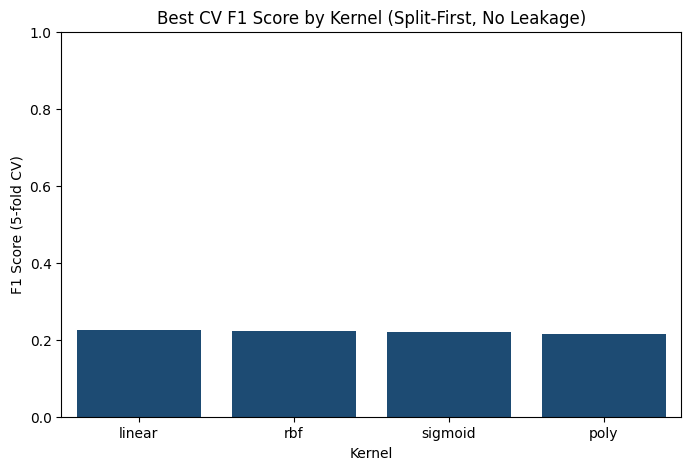

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=best_per_kernel, x='kernel', y='best_cv_f1', color="#0f4c81")
plt.title('Best CV F1 Score by Kernel (Split-First, No Leakage)')
plt.ylabel('F1 Score (5-fold CV)')
plt.xlabel('Kernel')
plt.ylim(0, 1)
plt.show()
